In [1]:
import tensorflow as tf
from tensorflow import keras
import os 
import zipfile
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [2]:
df = pd.read_csv('Training_set.csv')

In [3]:
df.head()

,filename,label
0,Image_1.jpg,SOUTHERN DOGFACE
1,Image_2.jpg,ADONIS
2,Image_3.jpg,BROWN SIPROETA
3,Image_4.jpg,MONARCH
4,Image_5.jpg,GREEN CELLED CATTLEHEART


In [4]:
df['label'].unique()

array(['SOUTHERN DOGFACE', 'ADONIS', 'BROWN SIPROETA', 'MONARCH',
       'GREEN CELLED CATTLEHEART', 'CAIRNS BIRDWING',
       'EASTERN DAPPLE WHITE', 'RED POSTMAN', 'MANGROVE SKIPPER',
       'BLACK HAIRSTREAK', 'CABBAGE WHITE', 'RED ADMIRAL', 'PAINTED LADY',
       'PAPER KITE', 'SOOTYWING', 'PINE WHITE', 'PEACOCK',
       'CHECQUERED SKIPPER', 'JULIA', 'COMMON WOOD-NYMPH', 'BLUE MORPHO',
       'CLOUDED SULPHUR', 'STRAITED QUEEN', 'ORANGE OAKLEAF',
       'PURPLISH COPPER', 'ATALA', 'IPHICLUS SISTER', 'DANAID EGGFLY',
       'LARGE MARBLE', 'PIPEVINE SWALLOW', 'BLUE SPOTTED CROW',
       'RED CRACKER', 'QUESTION MARK', 'CRIMSON PATCH', 'BANDED PEACOCK',
       'SCARCE SWALLOW', 'COPPER TAIL', 'GREAT JAY', 'INDRA SWALLOW',
       'VICEROY', 'MALACHITE', 'APPOLLO', 'TWO BARRED FLASHER',
       'MOURNING CLOAK', 'TROPICAL LEAFWING', 'POPINJAY', 'ORANGE TIP',
       'GOLD BANDED', 'BECKERS WHITE', 'RED SPOTTED PURPLE',
       'MILBERTS TORTOISESHELL', 'SILVER SPOT SKIPPER', 'AMERICAN SN

In [5]:
df['label'].value_counts()

label
MOURNING CLOAK    131
SLEEPY ORANGE     107
ATALA             100
BROWN SIPROETA     99
SCARCE SWALLOW     97
                 ... 
AMERICAN SNOOT     74
GOLD BANDED        73
MALACHITE          73
CRIMSON PATCH      72
WOOD SATYR         71
Name: count, Length: 75, dtype: int64

In [6]:
df.shape

(6499, 2)

In [7]:
train_data, val_data = train_test_split(df, test_size=0.2, random_state=42)

In [8]:
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)
val_datagen = ImageDataGenerator(
    rescale=1.0/255.0
)

In [9]:
image_size = (150,150)
batch_size = 32
epochs = 1  # modified from 40 for fast execution

In [10]:
train_data = datagen.flow_from_dataframe(
    dataframe=train_data,
    directory='train',  
    x_col='filename',            
    y_col='label',               
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
)

val_data = val_datagen.flow_from_dataframe(
    dataframe=val_data,
    directory='train',  
    x_col='filename',            
    y_col='label',               
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
)

Found 5199 validated image filenames belonging to 75 classes.
Found 1300 validated image filenames belonging to 75 classes.


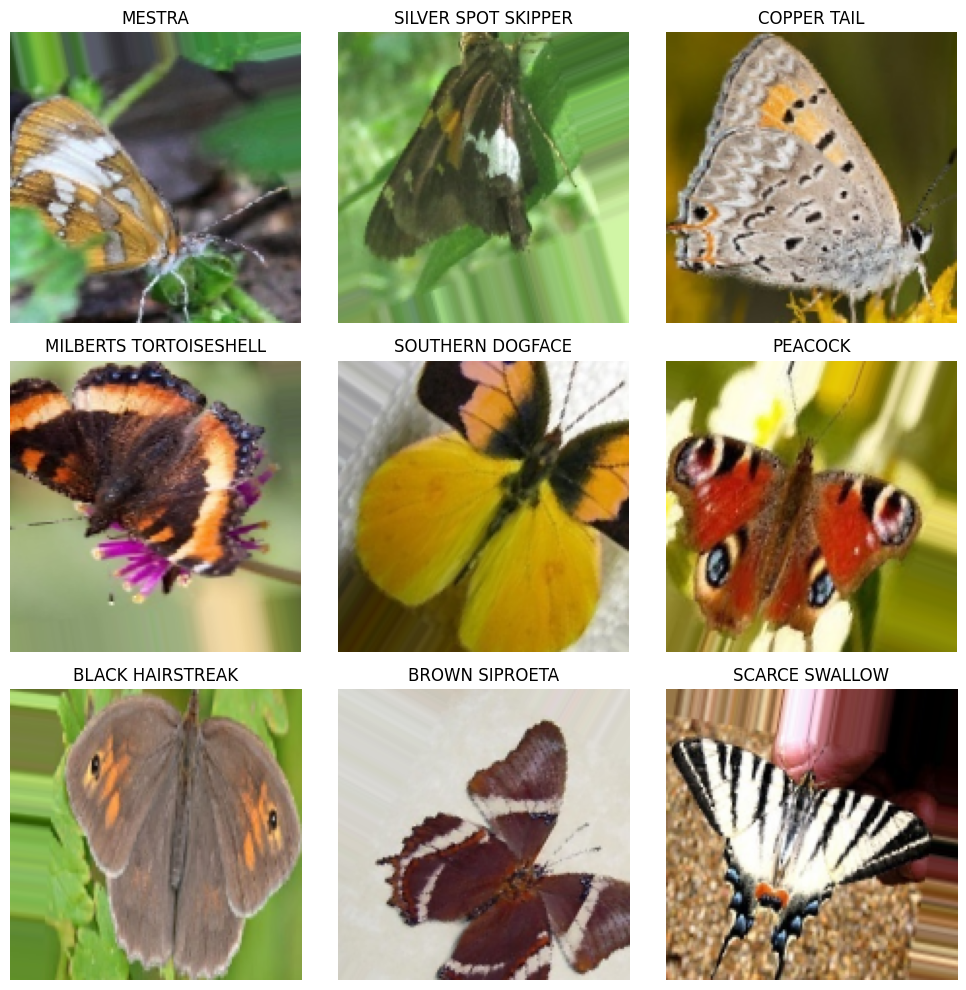

In [11]:
import matplotlib.pyplot as plt
import numpy as np

images, labels = next(train_data)

class_names = {v: k for k, v in train_data.class_indices.items()}

random_indices = np.random.choice(len(images), 9, replace=False)

plt.figure(figsize=(10, 10))
for i, idx in enumerate(random_indices):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[idx]) 
    label_index = np.argmax(labels[idx])  
    label_name = class_names[label_index]  
    plt.title(f"{label_name}")  
    plt.axis('off')  

plt.tight_layout()
plt.show()


# CNN Model

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Input(shape=(150,150,3)),   # ✅ modern way

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),

    Dense(df['label'].nunique(), activation='softmax')
])

In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 36992)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │      18,940,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 75)                  │          38,475 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 19,072,139 (72.75 MB)

 Trainable params: 19,072,139 (72.75 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(
      optimizer=tf.keras.optimizers.Adam(),
      loss='categorical_crossentropy',
      metrics=['accuracy']
  )


In [15]:
train_steps = int(train_data.n//batch_size)
val_steps = int(val_data.n//batch_size)

history = model.fit(train_data, 
          validation_data=val_data,
          epochs=epochs,
          steps_per_epoch=train_steps,
          validation_steps=val_steps)

Epoch 1/40
162/162 ━━━━━━━━━━━━━━━━━━━━ 170s 1s/step - accuracy: 0.0261 - loss: 4.1995 - val_accuracy: 0.0844 - val_loss: 3.8038
Epoch 2/40
  1/162 ━━━━━━━━━━━━━━━━━━━━ 1:05 409ms/step - accuracy: 0.0625 - loss: 3.8402

C:\Users\shriy\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


162/162 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.0625 - loss: 3.8402 - val_accuracy: 0.0812 - val_loss: 3.8193
Epoch 3/40
162/162 ━━━━━━━━━━━━━━━━━━━━ 79s 488ms/step - accuracy: 0.0954 - loss: 3.6443 - val_accuracy: 0.1820 - val_loss: 3.2435
Epoch 4/40
162/162 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.2188 - loss: 3.1656 - val_accuracy: 0.1820 - val_loss: 3.2501
Epoch 5/40
162/162 ━━━━━━━━━━━━━━━━━━━━ 79s 486ms/step - accuracy: 0.1947 - loss: 3.0745 - val_accuracy: 0.2602 - val_loss: 2.8513
Epoch 6/40
162/162 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.1875 - loss: 2.9316 - val_accuracy: 0.2570 - val_loss: 2.9134
Epoch 7/40
162/162 ━━━━━━━━━━━━━━━━━━━━ 81s 502ms/step - accuracy: 0.2721 - loss: 2.6939 - val_accuracy: 0.4133 - val_loss: 2.1193
Epoch 8/40
162/162 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.2812 - loss: 2.7304 - val_accuracy: 0.4242 - val_loss: 2.1032
Epoch 9/40
162/162 ━━━━━━━━━━━━━━━━━━━━ 79s 490ms/step - accuracy: 0.3313 - loss: 2.4295 - val_accurac

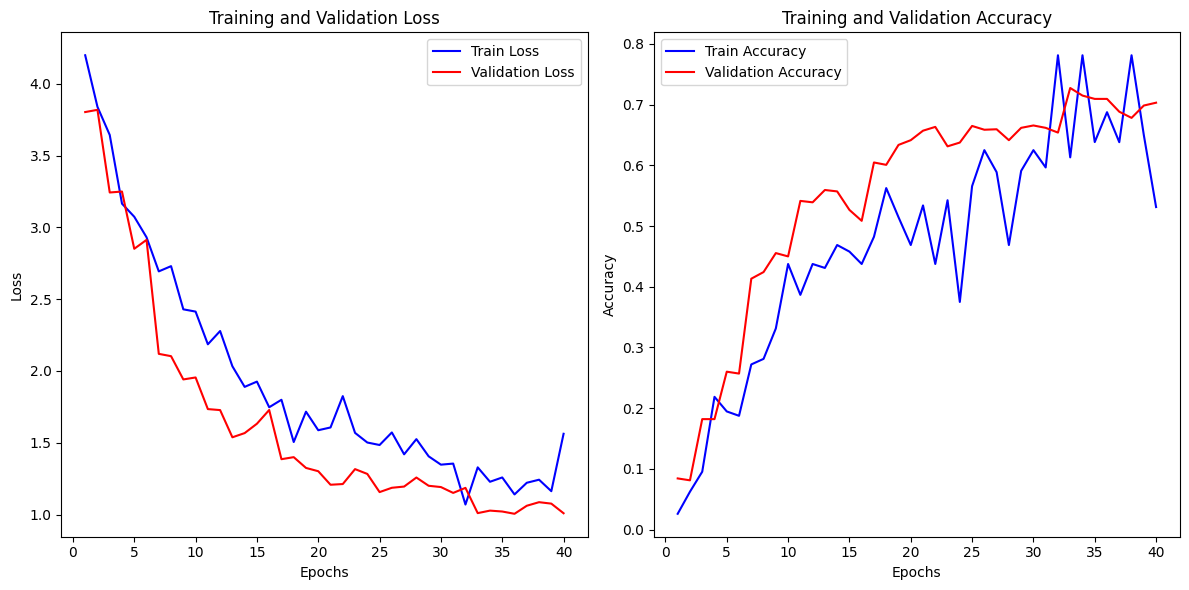

In [16]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

epochs = range(1, len(train_loss) + 1)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, label='Train Loss', color='blue')
plt.plot(epochs, val_loss, label='Validation Loss', color='red')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracy, label='Train Accuracy', color='blue')
plt.plot(epochs, val_accuracy, label='Validation Accuracy', color='red')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()


plt.tight_layout()
plt.show()

## THANK YOU!!